# 3D test: periodic target on the 3-torus, with rejuvenation

We train a Neural Circular Spline Flow (NCSF) $F$ on the 3-torus $\mathbb T^3 = [-\pi, \pi]^3$, then use the trained flow as a proposal for self-normalized importance sampling, *resample* to obtain equally-weighted particles, and finally *rejuvenate* them with overdamped Langevin dynamics that needs the gradient $\nabla U_1$.

- **Source:** $\mu_0 = \mathrm{Uniform}([-\pi, \pi]^3)$, with constant potential $U_0$.
- **Target:** a periodic von-Mises *ridge mixture* on $\mathbb T^3$,
$$
U_1(\theta) = -\log\Bigl[\,e^{\kappa\cos(\theta_1 - \theta_2)} + e^{\kappa\cos(\theta_2 - \theta_3)} + e^{\kappa\cos(\theta_3 - \theta_1)}\,\Bigr], \quad \kappa = 4.
$$
The density is genuinely periodic (only $\cos$ of differences appears), and concentrates on three intersecting *ridges* $\{\theta_i = \theta_j\} \subset \mathbb T^3$ — a target that an axis-aligned proposal cannot fit, but a circular spline flow can.
- **Flow:** $F$ is an NCSF; internally it composes circular shifts with monotonic rational-quadratic splines on the angular box $[-\pi, \pi]^3$, then conjugates by an affine to act on the user-specified box.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent)) # add project root to search path

import math
import torch
from zflows import NCSF, Potential, Uniform, compute_ESS_log, reverse_KL, resample, rejuvenation

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Source and target potentials

Both `Potential` subclasses return $U(x)$ for a batch of points $x \in [-\pi, \pi]^3$. By definition,
$$
\mu_0(x) \propto \exp(-U_0(x)), \qquad \mu_1(\theta) \propto \exp(-U_1(\theta)).
$$
As always with reverse-KL training, only $U_1$ is needed — never the normalizing constant of $\mu_1$.

In [4]:
# source: uniform on [-pi, pi]^3 (constant potential)
u0 = Uniform(a=[-math.pi, -math.pi, -math.pi], b=[math.pi, math.pi, math.pi]).to(device)

# target: von-Mises ridge mixture on the 3-torus
# U1(theta) = -log[ exp(k cos(t1-t2)) + exp(k cos(t2-t3)) + exp(k cos(t3-t1)) ]
class U1(Potential):
    def __init__(self, kappa: float = 4.0):
        super().__init__()
        self.kappa = kappa
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        t1, t2, t3 = x[:, 0], x[:, 1], x[:, 2]
        logits = torch.stack([
            self.kappa * torch.cos(t1 - t2),
            self.kappa * torch.cos(t2 - t3),
            self.kappa * torch.cos(t3 - t1),
        ], dim=-1) # [N, 3]
        return -torch.logsumexp(logits, dim=-1) # [N]

u1 = U1(kappa=4.0).to(device)

## NCSF and reverse-$\mathrm{KL}$ training

NCSF differs from NSF in that the inner univariate transform is a *circular* RQS spline: it composes a periodic shift with a monotonic spline on $[-\pi, \pi]$, so the resulting bijection respects the torus topology — densities are continuous (and $C^1$) when wrapped at $\pm\pi$. The reverse-$\mathrm{KL}$ loss is identical to the Euclidean case,
$$
\mathcal L_{\mathrm{reverse}}[F] = \mathbb E_{x \sim \mu_0}\bigl[\, U_1(F(x)) - \log |\det J_F(x)| \,\bigr],
$$
because `flow.t().call_and_ladj(x)` returns the same `(y, ladj)` interface.

In [5]:
flow = NCSF(
    a=[-math.pi, -math.pi, -math.pi],
    b=[ math.pi,  math.pi,  math.pi],
    bins=12, transforms=5, hidden_features=(64, 64),
).to(device)

N: int = 20000     # number of samples
LR: float = 1e-3   # learning rate
BATCH: int = 1000  # batch size
EPOCH: int = 20    # number of epochs

x = u0.samples(N)
optimizer = torch.optim.Adam(flow.parameters(), lr=LR)

for epoch in range(EPOCH):
    perm = torch.randperm(N, device=device)
    epoch_loss = 0.0
    n_batches = 0
    for start in range(0, N, BATCH):
        idx = perm[start:start + BATCH]
        x_batch = x[idx]

        loss = reverse_KL(x_batch, target=u1, flow=flow)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    print(f"epoch {epoch+1:>3}/{EPOCH}   KL_loss = {epoch_loss / n_batches:.6f}")

epoch   1/20   KL_loss = -3.024141
epoch   2/20   KL_loss = -3.204838
epoch   3/20   KL_loss = -3.280587
epoch   4/20   KL_loss = -3.318813
epoch   5/20   KL_loss = -3.344633
epoch   6/20   KL_loss = -3.361629
epoch   7/20   KL_loss = -3.373729
epoch   8/20   KL_loss = -3.387431
epoch   9/20   KL_loss = -3.395010
epoch  10/20   KL_loss = -3.400127
epoch  11/20   KL_loss = -3.408480
epoch  12/20   KL_loss = -3.413453
epoch  13/20   KL_loss = -3.421366
epoch  14/20   KL_loss = -3.424131
epoch  15/20   KL_loss = -3.428880
epoch  16/20   KL_loss = -3.433216
epoch  17/20   KL_loss = -3.436076
epoch  18/20   KL_loss = -3.443390
epoch  19/20   KL_loss = -3.446875
epoch  20/20   KL_loss = -3.450042


## Importance sampling and $\mathrm{ESS}$

With the trained flow as proposal $\nu = F_\# \mu_0$, the unnormalized log-weights are
$$
\log w(\theta) = -U_1(\theta) + U_0(x) + \log |\det J_F(x)|, \qquad \theta = F(x), \; x \sim \mu_0,
$$
and the Effective Sample Size $\mathrm{ESS} = (\sum w_i)^2 / (N \sum w_i^2) \in [0, 1]$ tells us how concentrated those weights are.

In [6]:
with torch.no_grad():
    x_plot = u0.samples(N)                            # fresh samples from source
    y_plot, ladj = flow.t().call_and_ladj(x_plot)     # pushforward F(x)
    # log w = -U_1(y) + U_0(x) + log|det J_F(x)|
    log_w = -u1(y_plot) + u0(x_plot) + ladj

ess = compute_ESS_log(log_w)
print(f"ESS = {ess.item():.4f}")

ESS = 0.7757


## Resampling: from weighted to equally-weighted particles

IS produces $N$ samples $\{\theta_i\}$ with unequal weights $\{w_i\}$. Many downstream uses (plotting, MCMC kernels, particle filters) want *equally-weighted* samples. Multinomial resampling draws indices $\{j_i\}_{i=1}^{N}$ i.i.d. from the categorical $\mathrm{Cat}(w_1, \dots, w_N)$ and returns $\{\theta_{j_i}\}$. Asymptotically the resulting empirical measure has the same target distribution, but with a discrete *empirical artefact*: many particles collapse onto the same locations. That artefact is exactly what the rejuvenation step below is designed to dissolve.

`resample(samples, weights)` does this in one line.

In [7]:
with torch.no_grad():
    w = (log_w - log_w.max()).exp()  # normalize-stable weights
    y_resampled = resample(y_plot, w)

## `enable_grad`: opt-in compiled gradients for `Potential`

The rejuvenation step needs $\nabla U_1(\theta)$. The base `Potential` class does **not** build a gradient by default — many use cases (forward-only sampling, IS evaluation, KL training) only need $U_1$ itself, and we don't want to pay the `torch.compile` startup cost or pull in `torch.func` for those. The `.enable_grad()` method is the opt-in:

```python
u1.enable_grad()       # builds .grad once, returns self for chaining
g = u1.grad(theta)     # [N, d], works without theta.requires_grad=True
```

Under the hood (in [`zflows/potential.py`](../zflows/potential.py)), it caches
$$
\nabla U_1 \;=\; \texttt{torch.compile}\bigl(\texttt{vmap}(\texttt{grad}(U_1))\bigr)
$$
so every subsequent `.grad(theta)` is a single fused kernel call, with no Python-level autograd graph construction. The call is **idempotent** — calling `.enable_grad()` twice is a no-op — and it raises a clear `RuntimeError` if you call `.grad(...)` without first calling `.enable_grad()`. The two `os.environ.setdefault(...)` lines below just suppress Triton's autotuning chatter and serialize Inductor's worker pool for cleaner output during the first compile.

In [8]:
import os
os.environ.setdefault("TRITON_PRINT_AUTOTUNING", "0")
os.environ.setdefault("TORCHINDUCTOR_COMPILE_THREADS", "1")  # cleaner logs

u1.enable_grad()  # opt-in: build .grad(x) only when needed

U1()

## Rejuvenation: overdamped Langevin

`rejuvenation` is an alias for `langevin`. Both apply $T$ steps of Euler-Maruyama on the overdamped Langevin SDE
$$
\mathrm{d}\theta_t \;=\; -\nabla U_1(\theta_t)\,\mathrm{d}t + \sqrt{2}\,\mathrm{d}B_t,
$$
whose unique invariant distribution is exactly $\mu_1 \propto \exp(-U_1)$. The discrete update is
$$
\theta_{k+1} \;=\; \theta_k \;-\; h\,\nabla U_1(\theta_k) \;+\; \sqrt{2h}\,\xi_k, \qquad \xi_k \sim \mathcal N(0, I_d),
$$
with default step $h = 10^{-3}$ and $T = 100$ iterations. After resampling we have many duplicate particles; Langevin moves them according to the gradient flow of $U_1$ (drifting toward modes) plus stochastic diffusion, which **breaks the duplicates apart** and decorrelates the particle cloud. In SMC/particle-filter terminology this step is called *rejuvenation*.

Why gradient flow + noise: pure gradient descent ($-\nabla U_1$) is mode-seeking and would collapse particles onto local minima. The $\sqrt{2h}$ noise is exactly calibrated so that, in the continuous-time limit, the stationary density is $\mu_1$ rather than a delta at the mode. Discretization adds an $O(h)$ bias; for tighter targets one would compose Langevin with a Metropolis-Hastings accept/reject step (MALA), but here the bias is small enough to ignore.

In [9]:
y_fresh = rejuvenation(y_resampled, potential=u1)  # default step / iters

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


## Visualization

We subsample the cloud to keep the 3D scatter readable, then render the rejuvenated particles. The three intersecting ridges of $U_1$ — $\{\theta_1 \approx \theta_2\}$, $\{\theta_2 \approx \theta_3\}$, $\{\theta_3 \approx \theta_1\}$ — should appear as three planar bands meeting along the diagonal $\theta_1 = \theta_2 = \theta_3$ of the cube $[-\pi, \pi]^3$.

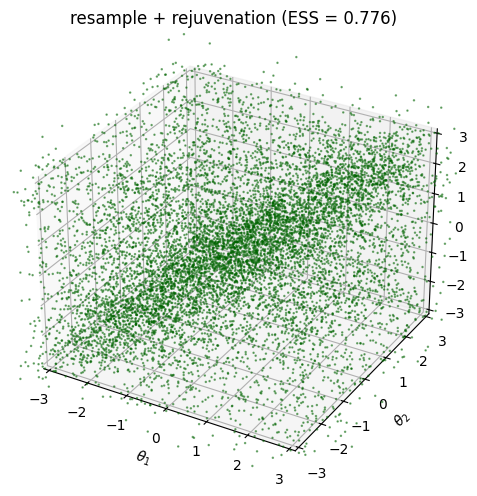

In [10]:
import matplotlib.pyplot as plt

N_PLOT = 10000
idx_plot = torch.randperm(y_fresh.shape[0])[:N_PLOT]
y_fresh_np = y_fresh[idx_plot].detach().cpu().numpy()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(y_fresh_np[:, 0], y_fresh_np[:, 1], y_fresh_np[:, 2], s=0.6, alpha=0.5, color="darkgreen")
ax.set_xlim(-math.pi, math.pi)
ax.set_ylim(-math.pi, math.pi)
ax.set_zlim(-math.pi, math.pi)
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_zlabel(r"$\theta_3$")
ax.set_title(f"resample + rejuvenation (ESS = {ess.item():.3f})")

plt.tight_layout()
plt.show()

## Recap of the pipeline

1. **Train.** Reverse-KL fits an NCSF proposal $\nu = F_\# \mu_0$ to the target $\mu_1 \propto \exp(-U_1)$, using only $U_1$ (no target samples).
2. **Importance sampling.** Push $\mu_0$-samples through $F$, compute log-weights $\log w = -U_1(F(x)) + U_0(x) + \log|\det J_F|$, report $\mathrm{ESS}$ as a self-test.
3. **Resample.** Multinomial resampling $\{\theta_i, w_i\} \to \{\theta_{j_i}\}$ converts a weighted cloud into an equally-weighted cloud (with duplicate particles).
4. **Enable gradients.** `u1.enable_grad()` builds a `torch.compile`-compiled `vmap(grad(U_1))` once and caches it on the instance.
5. **Rejuvenate.** Overdamped Langevin (alias `rejuvenation`) breaks the duplicates apart and slightly corrects residual proposal bias by simulating an SDE whose stationary density is exactly $\mu_1$.

The NCSF + IS + resample + Langevin pipeline is the basic building block of *flow-augmented SMC* on manifolds: the flow gives a good global proposal, IS provides unbiased correction, and Langevin gives local mixing using the geometry of $U_1$ itself.